In [1]:
import os
import sys
sys.path.insert(0, os.path.abspath('..'))

import io
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from utils import read_log

# ROUND 1

In [2]:
path = '../backtests/round_1/submission.log'
with open(path, 'r') as f:
    data = json.load(f)

In [3]:
data.keys()

dict_keys(['submissionId', 'activitiesLog', 'logs', 'tradeHistory'])

In [4]:
activities = pd.read_csv(io.StringIO(data['activitiesLog']), sep=';')
trades = pd.DataFrame(data['tradeHistory'])

In [5]:
price_pepper = activities[activities['product'] == 'INTARIAN_PEPPER_ROOT'].reset_index(drop=True).set_index('timestamp')
price_osmium = activities[activities['product'] == 'ASH_COATED_OSMIUM'].reset_index(drop=True).set_index('timestamp')
trades_pepper = trades[trades['symbol'] == 'INTARIAN_PEPPER_ROOT'].reset_index(drop=True).set_index('timestamp')
trades_osmium = trades[trades['symbol'] == 'ASH_COATED_OSMIUM'].reset_index(drop=True).set_index('timestamp')

In [6]:
print(f'Pepper First 1000 ts PnL: {price_pepper['profit_and_loss'].iloc[999]}')
print(f'Osmium First 1000 ts PnL: {price_osmium['profit_and_loss'].iloc[999]}')
print(f'Total First 1000 ts PnL: {price_pepper['profit_and_loss'].iloc[999] + price_osmium['profit_and_loss'].iloc[999]}')
print()
print(f'Pepper Final PnL: {price_pepper['profit_and_loss'].iloc[-1]}')
print(f'Osmium Final PnL: {price_osmium['profit_and_loss'].iloc[-1]}')
print(f'Total Final PnL: {price_pepper['profit_and_loss'].iloc[-1] + price_osmium['profit_and_loss'].iloc[-1]}')

Pepper First 1000 ts PnL: 7365.0
Osmium First 1000 ts PnL: 2149.0
Total First 1000 ts PnL: 9514.0

Pepper Final PnL: 80405.0
Osmium Final PnL: 19568.0
Total Final PnL: 99973.0


In [7]:
trades_pepper = trades_pepper.assign(
    traded=lambda x: np.where(
        x['buyer'] == 'SUBMISSION',
        x['quantity'],
        np.where(
            x['seller'] == 'SUBMISSION',
            -x['quantity'],
            0
        )
    )
)
trades_pepper = trades_pepper.assign(position=lambda x: np.cumsum(x['traded']))
trades_osmium = trades_osmium.assign(
    traded=lambda x: np.where(
        x['buyer'] == 'SUBMISSION',
        x['quantity'],
        np.where(
            x['seller'] == 'SUBMISSION',
            -x['quantity'],
            0
        )
    )
)
trades_osmium = trades_osmium.assign(position=lambda x: np.cumsum(x['traded']))

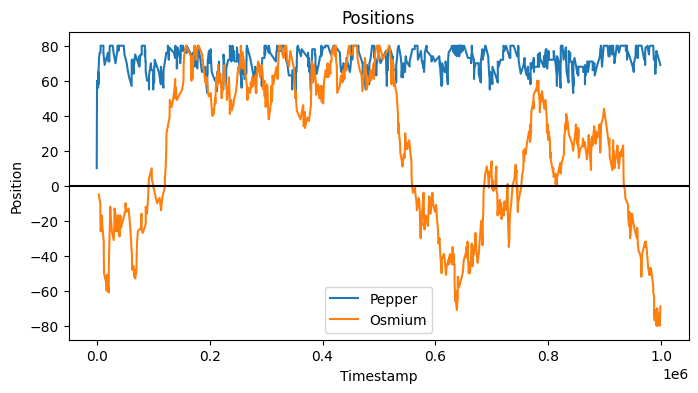

In [8]:
plt.figure(figsize=(8, 4))
plt.plot(trades_pepper['position'], label='Pepper')
plt.plot(trades_osmium['position'], label='Osmium')
plt.axhline(0, c='k')
plt.xlabel('Timestamp')
plt.ylabel('Position')
plt.title('Positions')
plt.legend()
plt.show()

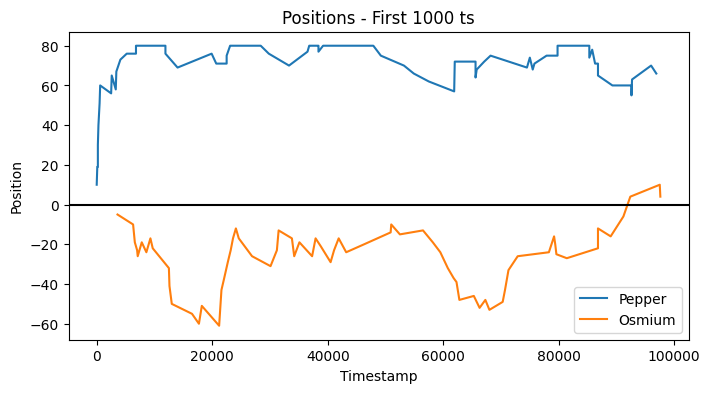

In [9]:
plt.figure(figsize=(8, 4))
plt.plot(trades_pepper['position'].loc[:99900], label='Pepper')
plt.plot(trades_osmium['position'].loc[:99900], label='Osmium')
plt.axhline(0, c='k')
plt.xlabel('Timestamp')
plt.ylabel('Position')
plt.title('Positions - First 1000 ts')
plt.legend()
plt.show()

In [10]:
pepper_pnl = price_pepper[price_pepper['profit_and_loss'] >= -1000][price_pepper['profit_and_loss'] <= 70000]['profit_and_loss'].loc[:99900]
osmium_pnl = price_osmium[price_osmium['profit_and_loss'] >= -1000][price_osmium['profit_and_loss'] <= 70000]['profit_and_loss'].loc[:99900]

C:\Users\aeali\AppData\Local\Temp\ipykernel_23076\1080791694.py:1: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  pepper_pnl = price_pepper[price_pepper['profit_and_loss'] >= -1000][price_pepper['profit_and_loss'] <= 70000]['profit_and_loss'].loc[:99900]
C:\Users\aeali\AppData\Local\Temp\ipykernel_23076\1080791694.py:2: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  osmium_pnl = price_osmium[price_osmium['profit_and_loss'] >= -1000][price_osmium['profit_and_loss'] <= 70000]['profit_and_loss'].loc[:99900]


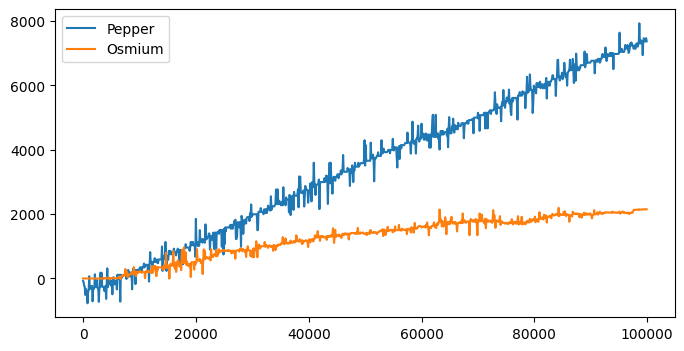

In [11]:
plt.figure(figsize=(8, 4))
plt.plot(pepper_pnl, label='Pepper')
plt.plot(osmium_pnl, label='Osmium')
plt.legend()
plt.show()

# ROUND 2

In [12]:
path = '../backtests/round_2/submission.log'
with open(path, 'r') as f:
    data = json.load(f)

activities = pd.read_csv(io.StringIO(data['activitiesLog']), sep=';')
trades = pd.DataFrame(data['tradeHistory'])

price_pepper = activities[activities['product'] == 'INTARIAN_PEPPER_ROOT'].reset_index(drop=True).set_index('timestamp')
price_osmium = activities[activities['product'] == 'ASH_COATED_OSMIUM'].reset_index(drop=True).set_index('timestamp')
trades_pepper = trades[trades['symbol'] == 'INTARIAN_PEPPER_ROOT'].reset_index(drop=True).set_index('timestamp')
trades_osmium = trades[trades['symbol'] == 'ASH_COATED_OSMIUM'].reset_index(drop=True).set_index('timestamp')

In [13]:
print(f'Pepper First 1000 ts PnL: {price_pepper['profit_and_loss'].iloc[999]}')
print(f'Osmium First 1000 ts PnL: {price_osmium['profit_and_loss'].iloc[999]}')
print(f'Total First 1000 ts PnL: {price_pepper['profit_and_loss'].iloc[999] + price_osmium['profit_and_loss'].iloc[999]}')
print()
print(f'Pepper Final PnL: {price_pepper['profit_and_loss'].iloc[-1]}')
print(f'Osmium Final PnL: {price_osmium['profit_and_loss'].iloc[-1]}')
print(f'Total Final PnL: {price_pepper['profit_and_loss'].iloc[-1] + price_osmium['profit_and_loss'].iloc[-1]}')

Pepper First 1000 ts PnL: 7472.0
Osmium First 1000 ts PnL: 1793.0
Total First 1000 ts PnL: 9265.0

Pepper Final PnL: 80573.0
Osmium Final PnL: 20458.0
Total Final PnL: 101031.0


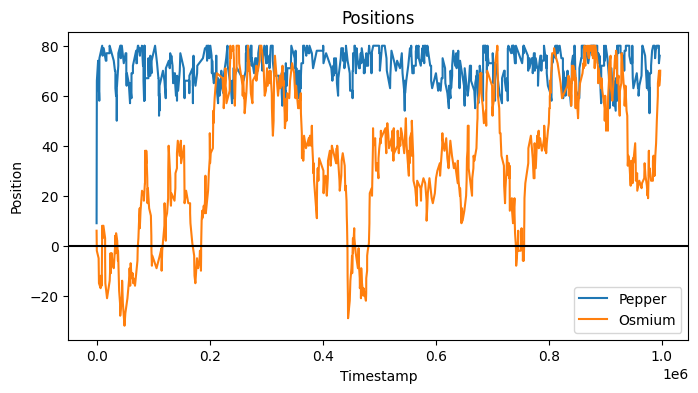

In [14]:
trades_pepper = trades_pepper.assign(
    traded=lambda x: np.where(
        x['buyer'] == 'SUBMISSION',
        x['quantity'],
        np.where(
            x['seller'] == 'SUBMISSION',
            -x['quantity'],
            0
        )
    )
)
trades_pepper = trades_pepper.assign(position=lambda x: np.cumsum(x['traded']))
trades_osmium = trades_osmium.assign(
    traded=lambda x: np.where(
        x['buyer'] == 'SUBMISSION',
        x['quantity'],
        np.where(
            x['seller'] == 'SUBMISSION',
            -x['quantity'],
            0
        )
    )
)
trades_osmium = trades_osmium.assign(position=lambda x: np.cumsum(x['traded']))

plt.figure(figsize=(8, 4))
plt.plot(trades_pepper['position'], label='Pepper')
plt.plot(trades_osmium['position'], label='Osmium')
plt.axhline(0, c='k')
plt.xlabel('Timestamp')
plt.ylabel('Position')
plt.title('Positions')
plt.legend()
plt.show()

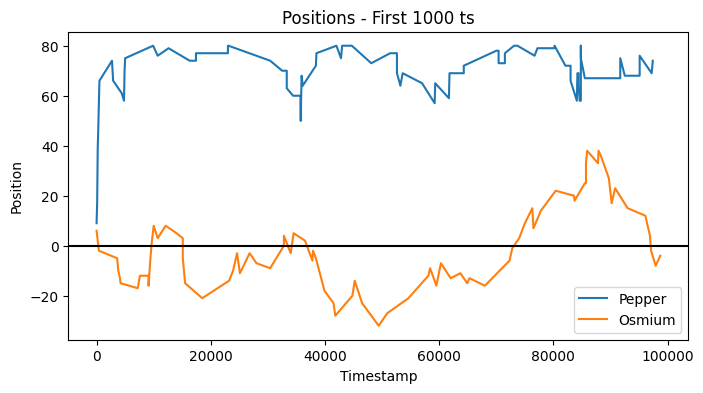

In [15]:
plt.figure(figsize=(8, 4))
plt.plot(trades_pepper['position'].loc[:99900], label='Pepper')
plt.plot(trades_osmium['position'].loc[:99900], label='Osmium')
plt.axhline(0, c='k')
plt.xlabel('Timestamp')
plt.ylabel('Position')
plt.title('Positions - First 1000 ts')
plt.legend()
plt.show()

C:\Users\aeali\AppData\Local\Temp\ipykernel_23076\2500109934.py:1: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  pepper_pnl = price_pepper[price_pepper['profit_and_loss'] >= -1000][price_pepper['profit_and_loss'] <= 70000]['profit_and_loss'].loc[:99900]
C:\Users\aeali\AppData\Local\Temp\ipykernel_23076\2500109934.py:2: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  osmium_pnl = price_osmium[price_osmium['profit_and_loss'] >= -1000][price_osmium['profit_and_loss'] <= 70000]['profit_and_loss'].loc[:99900]


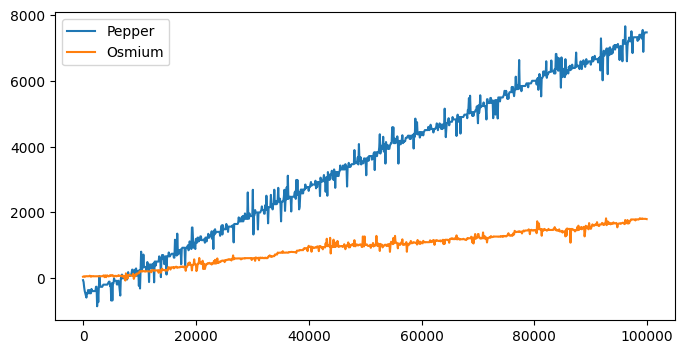

In [16]:
pepper_pnl = price_pepper[price_pepper['profit_and_loss'] >= -1000][price_pepper['profit_and_loss'] <= 70000]['profit_and_loss'].loc[:99900]
osmium_pnl = price_osmium[price_osmium['profit_and_loss'] >= -1000][price_osmium['profit_and_loss'] <= 70000]['profit_and_loss'].loc[:99900]

plt.figure(figsize=(8, 4))
plt.plot(pepper_pnl, label='Pepper')
plt.plot(osmium_pnl, label='Osmium')
plt.legend()
plt.show()

# ROUND 3 